In [1]:
import gymnasium as gym
import gym_unbalanced_disk, time
import gymnasium.wrappers
import torch
import numpy as np

from torch import nn
from copy import deepcopy
from matplotlib import pyplot as plt

if not hasattr(gym_unbalanced_disk.UnbalancedDisk, '_old_reset'):
    gym_unbalanced_disk.UnbalancedDisk._old_reset = gym_unbalanced_disk.UnbalancedDisk.reset

def patched_reset(self, seed=None, options=None):
    # Call the original reset without the new keyword parameters
    return self._old_reset()

gym_unbalanced_disk.UnbalancedDisk.reset = patched_reset

raw_env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, umax=3.) 
env = gym.wrappers.TimeLimit(raw_env, max_episode_steps=200)


#env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, umax=3.) #alternative

obs, info = env.reset()
try:
    for i in range(200):
        obs, reward, terminated, truncated, info = env.step(env.action_space.sample()) #random action
        print(obs, reward)
        env.render()
        time.sleep(1/24)
        if terminated or truncated:
            obs = env.reset()
finally: #this will always run
    env.close()

[-0.01658648 -1.37444257] 2.9654990840796265e-11
[-0.07232856 -3.05816878] 7.005891759977955e-11
[-0.13381045 -1.82719804] 1.7682816431349884e-10
[-0.17388942 -1.37293719] 3.2103614814281597e-10
[-0.22398249 -2.5237968 ] 6.579554718239997e-10
[-0.28670024 -2.42407721] 1.605588728423336e-09
[-0.31932511 -0.1992484 ] 2.5503724973264904e-09
[-0.328914   -0.63805884] 2.9560518923605004e-09
[-0.3104983  1.9999267] 2.3024023369830414e-09
[-0.24443694  3.40923734] 8.737606731176618e-10
[-0.15541907  3.57782916] 2.4183095145397044e-10
[-0.05649097  4.31755914] 5.401542882879288e-11
[0.05194077 4.15854773] 5.052419588374288e-11
[0.16476612 4.89990265] 2.814343835570213e-10
[0.29795624 5.66998607] 1.9237689176834803e-09
[0.41145595 3.40197422] 9.306431317549334e-09
[0.47341976 1.47303224] 2.1118986931108532e-08
[0.49703168 0.36758861] 2.862076021517547e-08
[ 0.46974586 -2.29096329] 2.0664004713845692e-08
[ 0.42367314 -1.53325586] 1.087145098795746e-08
[ 0.398087   -0.54095786] 7.637667723053617e

In [3]:
class Qfunction(nn.Module):
    def __init__(self, env):
        super(Qfunction,self).__init__()
        self.lay1 = nn.Linear(env.observation_space.shape[0], 128) #a)
        self.F1 =  nn.Tanh() #a)
        self.lay2 = nn.Linear(128, num_actions) #a)
    
    def forward(self, obs):
        return self.lay2(self.F1(self.lay1(obs))) #a)

max_episode_steps = 500
env = gym.make('unbalanced-disk-sincos-v0', dt=0.025, umax=3.) 
env = gym.wrappers.TimeLimit(env,max_episode_steps=max_episode_steps) 

def make_env():
    env = gym.make('unbalanced-disk-sincos-v0')
    env.unwrapped.reward_fun = lambda self: 0.5 * (1.0 - np.cos(self.th))**2
    return env

env = make_env()

# Definition of discrete actions
discrete_actions = np.array([
    -3.0, -2.0, -1.0, -0.5, -0.25,
    -0.1, -0.05, -0.02,
     0.0,
     0.02, 0.05, 0.1,
     0.25, 0.5, 1.0, 2.0, 3.0
])
num_actions = len(discrete_actions)

Q = Qfunction(env)
#test validity:
obs, info = env.reset()
obs_tensor = torch.tensor(obs,dtype=torch.float32)[None,:] #convert to an torch tensor with size (1, Nobs=6)
print('obs_tensor = ', obs_tensor)
print('Q(x) = ',Q(obs_tensor)) #output #(1,Naction=3)

obs_tensor =  tensor([[-2.6666e-03,  1.0000e+00,  4.2900e-04]])
Q(x) =  tensor([[ 0.2831,  0.1554, -0.2083, -0.1051, -0.0406, -0.2177,  0.1008,  0.1139,
          0.1787, -0.2749,  0.2961,  0.0076, -0.0014,  0.3684,  0.2641, -0.1321,
          0.1896]], grad_fn=<AddmmBackward0>)


C:\Users\Earst\anaconda3\envs\ml4sc\Lib\site-packages\gymnasium\utils\passive_env_checker.py:133: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
C:\Users\Earst\anaconda3\envs\ml4sc\Lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [4]:
#visualize
def show(Q,env):
    with torch.no_grad():
        #you can use Qfun(obs) as a shorthand for the q function.
        Qfun = lambda x: Q(torch.tensor(x[None,:],dtype=torch.float32))[0].numpy() #convert x to torch.tensor -> put in the Q function -> back to numpy
        try:
            obs, info = env.reset() #b)
            env.render() #b)
            time.sleep(1) #b)
            while True: #b)
                action = np.argmax(Qfun(obs)) #b)
                voltage_action = float(discrete_actions[action])
                obs, reward, terminated, truncated, info = env.step(voltage_action) #b)
                time.sleep(1/60) #b)
                env.render() #b)
                if terminated or truncated: #b)
                    time.sleep(0.5)  #b)
                    break  #b)
        finally: #this will always run even when an error occurs
            env.close()
 
Q = Qfunction(env)
#show(Q,env)

In [5]:
def rollout(Q, env, epsilon=0.1, N_rollout=10_000): 
    # Save the following arrays (using .append)
    Start_state = [] # hold an array of (x_t)
    Actions = []     # hold an array of (u_t)
    Rewards = []     # hold an array of (r_{t+1})
    End_state = []   # hold an array of (x_{t+1})
    Terminal = []    # hold an array of (terminal_{t+1})
    
    # Qfun(a numpy array of the obs) -> a numpy array of Q values
    Qfun = lambda x: Q(torch.tensor(x[None, :], dtype=torch.float32))[0].numpy() 
    
    with torch.no_grad():
        obs, info = env.reset()
        obs = obs + np.array([
            np.random.normal(0, 0.01),
            np.random.normal(0, 0.01),
            np.random.normal(0, 0.3)
            ])
        obs = np.array(obs, dtype=np.float32) 
        
        for i in range(N_rollout): 
            if np.random.uniform() > epsilon: 
                Qnow = Qfun(obs) 
                action = np.argmax(Qnow) 
            else: 
                action = np.random.randint(0, num_actions) 
                
            Start_state.append(obs) 
            Actions.append(action) 

            # FIX: Get the raw scalar float number out of the array mapping
            voltage_action = float(discrete_actions[action])
            
            # Pass the raw scalar value directly to the step function
            obs_next, reward, terminated, truncated, info = env.step(voltage_action) 
            obs_next = obs_next + np.array([
                np.random.normal(0, 0.01),
                np.random.normal(0, 0.01),
                np.random.normal(0, 0.3)
                ])
            obs_next = np.array(obs_next, dtype=np.float32) 

            Terminal.append(terminated) 
            Rewards.append(reward) 
            End_state.append(obs_next) 

            if terminated or truncated: 
                obs, info = env.reset() 
                obs = obs + np.array([
                    np.random.normal(0, 0.01),
                    np.random.normal(0, 0.01),
                    np.random.normal(0, 0.3)
                    ])
                obs = np.array(obs, dtype=np.float32) 
            else: 
                obs = obs_next 
                
    assert len(Start_state) == len(Actions) == len(Rewards) == len(End_state) == len(Terminal), \
        f'error in lengths: {len(Start_state)}=={len(Actions)}=={len(Rewards)}=={len(End_state)}=={len(Terminal)}'
        
    return np.array(Start_state), np.array(Actions), np.array(Rewards), np.array(End_state), np.array(Terminal).astype(int)

# Trigger and test
Q = Qfunction(env) 
Start_state, Actions, Rewards, End_state, Terminal = rollout(Q, env, N_rollout=300)
print("Data collected successfully! Shapes:")
print(f"States: {Start_state.shape}, Actions: {Actions.shape}, Rewards: {Rewards.shape}")

C:\Users\Earst\anaconda3\envs\ml4sc\Lib\site-packages\gymnasium\utils\passive_env_checker.py:133: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
C:\Users\Earst\anaconda3\envs\ml4sc\Lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Data collected successfully! Shapes:
States: (300, 3), Actions: (300,), Rewards: (300,)


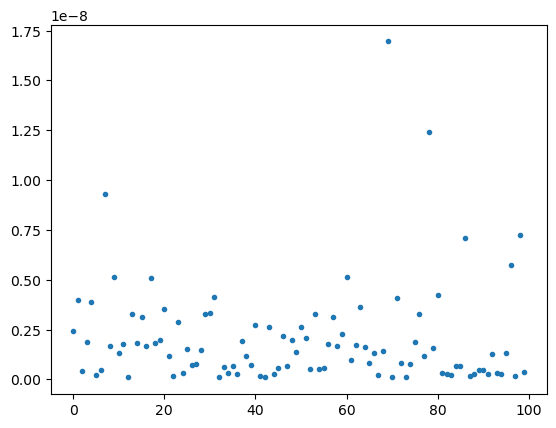

In [6]:
def eval_Q(Q,env):
    with torch.no_grad():
        Qfun = lambda x: Q(torch.tensor(x[None,:],dtype=torch.float32))[0].numpy()
        rewards_acc = 0 #d)
        obs, info = env.reset() #d)
        while True: #d)
            action = np.argmax(Qfun(obs)) #d)
            voltage_action = float(discrete_actions[action])
            obs, reward, terminated, truncated, info = env.step(voltage_action) #d)
            rewards_acc += reward #d)
            if terminated or truncated: #d)
                return rewards_acc #d)

Q = Qfunction(env) 
plt.plot([eval_Q(Q,env) for i in range(100)],'.') #d)
plt.show() #d)

In [19]:
def DQN_rollout(Q, optimizer, env, gamma=0.98, use_target_net=False, N_iterations=21, N_rollout=20000, \
                N_epochs=10, batch_size=32, N_evals=10, target_net_update_feq=100):
    best = -float('inf')
    torch.save(Q.state_dict(),'Q-checkpoint')
    try:
        for iteration in range(N_iterations):
            epsilon = max(0.05, 1.0 - iteration/(N_iterations*1.5))
            print(f'rollout iteration {iteration} with epsilon={epsilon:.2%}...')
            
            #2. rollout
            Start_state, Actions, Rewards, End_state, Terminal = rollout(Q, env, epsilon=epsilon, N_rollout=N_rollout) #e) 2.
            
            #Data conversion, no changes required
            convert = lambda x: [torch.tensor(xi,dtype=torch.float32) for xi in x]
            Start_state, Rewards, End_state, Terminal = convert([Start_state, Rewards, End_state, Terminal])
            Actions = Actions.astype(int)

            # Shuffle rollout data before batching
            perm = torch.randperm(len(Start_state))
            Start_state = Start_state[perm]
            Actions      = Actions[perm]
            Rewards      = Rewards[perm]
            End_state    = End_state[perm]
            Terminal     = Terminal[perm]

            print('starting training on rollout information...')
            t = 0
            for epoch in range(N_epochs): 
                for i in range(batch_size,len(Start_state)+1,batch_size): 
                    if t%target_net_update_feq==0:
                        Qtarget = deepcopy(Q) #g)
                        pass
                    t += 1
                    
                    Start_state_batch, Actions_batch, Rewards_batch, End_state_batch, Terminal_batch = [d[i-batch_size:i] for d in \
                                                                                                        [Start_state, Actions, Rewards, End_state, Terminal]] #e=) 3.
                    
                    with torch.no_grad(): #3.
                        if use_target_net:
                            pass
                            maxQ = torch.max(Qtarget(End_state_batch),dim=1)[0] #g)
                        else:
                            maxQ = torch.max(Q(End_state_batch),dim=1)[0] #e=) 3.
                    
                    # action_index = np.stack((np.arange(batch_size),Actions_batch),axis=0)
                    # ids = np.arange(batch_size)
                    
                    Qnow = Q(Start_state_batch)
                    # print(f'{action_index.shape=}')
                    # print(f'{Qnow.shape=}')
                    Qnow = Qnow[np.arange(batch_size), Actions_batch] #Q(x_t,u_t) is given
                    # print(Rewards_batch.shape, maxQ.shape, Terminal_batch.shape, Qnow.shape)
                    Loss = torch.mean((Rewards_batch + gamma*maxQ*(1-Terminal_batch) - Qnow)**2) #e) 3.
                    optimizer.zero_grad() #e) 3.
                    Loss.backward() #e) 3.
                    optimizer.step() #e) 3.
                
            score = np.mean([eval_Q(Q,env) for i in range(N_evals)])
            print(f'iteration={iteration} Average Reward per episode: {score:.2f}')
            if score > best:
                best = score
                print('################################# \n new best',best,'saving Q... \n#################################')
                torch.save(Q.state_dict(),'Q-checkpoint')
            
            print('loading best result')
            Q.load_state_dict(torch.load('Q-checkpoint'))
    finally: #this will always run even when using the a KeyBoard Interrupt. 
        print('loading best result')
        Q.load_state_dict(torch.load('Q-checkpoint'))

In [22]:
gamma = 0.999 #f=)
batch_size = 64 #f=)
N_iterations = 40 #f=)
N_rollout = 20000 #f=)
N_epochs = 6 #f=)
N_evals = 5 #f=)
lr = 0.005 #given
target_net_update_feq = 200

Q = Qfunction(env)
optimizer = torch.optim.Adam(Q.parameters(),lr=lr) #low learning rate
DQN_rollout(Q, optimizer, env, use_target_net=True, gamma=gamma, N_iterations=N_iterations, \
            N_rollout=N_rollout, N_epochs=N_epochs, N_evals=N_evals, batch_size=batch_size, \
            target_net_update_feq=target_net_update_feq)

rollout iteration 0 with epsilon=100.00%...
starting training on rollout information...
iteration=0 Average Reward per episode: 1.23
################################# 
 new best 1.2269663265944175 saving Q... 
#################################
loading best result
rollout iteration 1 with epsilon=98.33%...
starting training on rollout information...
iteration=1 Average Reward per episode: 0.00
loading best result
rollout iteration 2 with epsilon=96.67%...
starting training on rollout information...
iteration=2 Average Reward per episode: 10.78
################################# 
 new best 10.781356524689674 saving Q... 
#################################
loading best result
rollout iteration 3 with epsilon=95.00%...
starting training on rollout information...
iteration=3 Average Reward per episode: 9.48
loading best result
rollout iteration 4 with epsilon=93.33%...
starting training on rollout information...
iteration=4 Average Reward per episode: 0.35
loading best result
rollout iteratio

In [ ]:
# 1. Load the optimal weights from your best training checkpoint
Q.load_state_dict(torch.load('Q-checkpoint'))

env.metadata = {"render_modes": ["human"]}

# 2. Re-verify the visualization routine with scalar stepping
def watch_final_policy(Q, env):
    with torch.no_grad():
        # Setup the Q-value inference lambda function
        Qfun = lambda x: Q(torch.tensor(x[None, :], dtype=torch.float32))[0].numpy() 
        
        try:
            obs, info = env.reset() 
            env.render() # Opens the simulator visual display window
            time.sleep(1) # Brief pause so you can get ready to watch
            
            rewards_accumulator = 0
            while True: 
                # Network predicts the discrete action choice index (0 to 6)
                action_idx = np.argmax(Qfun(obs)) 
                
                # Extract the pure scalar voltage matching your disk environment requirements
                voltage_action = float(discrete_actions[action_idx])
                
                # Step the environment forward using the pure scalar value
                obs_next, reward, terminated, truncated, info = env.step(voltage_action) 
                obs = np.array(obs_next, dtype=np.float32) 
                
                rewards_accumulator += reward
                
                # Match the step time delta (dt=0.025) for a smooth, true-to-life animation speed
                time.sleep(0.025) 
                env.render() 
                
                if terminated or truncated: 
                    print(f"Episode finished! Total accumulated reward: {rewards_accumulator:.2f}")
                    time.sleep(1.0) # Hold the final frame for a second
                    break  
        finally: 
            env.close() # Clean up and close the visualization window safely

# 3. Trigger the animation
watch_final_policy(Q, env)

In [34]:
Q.load_state_dict(torch.load('Q-checkpoint'))
show(Q, env)

In [11]:
import gym_unbalanced_disk
import gymnasium
import numpy as np
import torch
from matplotlib import pyplot as plt

umax = 3.0

Q.load_state_dict(torch.load('Q-checkpoint'))
Q.eval()

env = gym_unbalanced_disk.UnbalancedDisk_exp(
    umax=umax,
    dt=0.025
)

# logs
theta_list = []
theta_deg_list = []
omega_list = []
action_list = []
reward_list = []
qvalue_list = []

obs, info = env.reset()

print("=== REAL HARDWARE DEBUG ===")

try:

    with torch.no_grad():

        Qfun = lambda x: Q(
            torch.tensor(x[None,:], dtype=torch.float32)
        )[0].numpy()

        for step in range(600):

            # --------------------------------------------------
            # Estado recibido del hardware
            # --------------------------------------------------

            th = float(obs[0])
            omega = float(obs[1])

            obs_sincos = np.array([
                np.sin(th),
                np.cos(th),
                omega
            ], dtype=np.float32)

            # --------------------------------------------------
            # Evaluar red
            # --------------------------------------------------

            qvals = Qfun(obs_sincos)

            action_idx = np.argmax(qvals)

            voltage = float(
                discrete_actions[action_idx]
            )

            # --------------------------------------------------
            # Logs
            # --------------------------------------------------

            theta_deg = np.degrees(
                np.arctan2(
                    obs_sincos[0],
                    obs_sincos[1]
                )
            )

            theta_list.append(th)
            theta_deg_list.append(theta_deg)
            omega_list.append(omega)
            action_list.append(voltage)
            qvalue_list.append(qvals.copy())

            # --------------------------------------------------
            # Debug cada 20 pasos
            # --------------------------------------------------

            if step % 20 == 0:

                print(
                    f"step={step:4d}"
                    f" | theta={theta_deg:7.1f}°"
                    f" | omega={omega:8.3f}"
                    f" | u={voltage:5.2f}V"
                )

                print(
                    f"    sin={obs_sincos[0]: .3f}"
                    f" cos={obs_sincos[1]: .3f}"
                )

                print(
                    f"    Qmax={np.max(qvals): .3f}"
                    f"  Qmin={np.min(qvals): .3f}"
                )

            # --------------------------------------------------
            # Aplicar acción
            # --------------------------------------------------

            obs, reward, terminated, truncated, info = env.step(
                voltage
            )

            reward_list.append(reward)

            if terminated or truncated:

                print(
                    f"\nEpisode ended at step {step}"
                )

                break

finally:

    print("\nStopping hardware safely...")

    env.reset()
    env.close()


NoBackendError: No backend available

In [28]:
import numpy as np
import torch
from matplotlib import pyplot as plt

# Load best network
Q.load_state_dict(torch.load('Q-checkpoint'))
Q.eval()

# Create fresh simulation environment
env = make_env()

# Storage
theta_list = []
omega_list = []
u_list = []
reward_list = []

obs, info = env.reset()

with torch.no_grad():

    for k in range(500):

        # Save state
        theta = np.arctan2(obs[0], obs[1])   # recover angle from sin/cos
        omega = obs[2]

        theta_list.append(np.degrees(theta))
        omega_list.append(omega)

        # DQN action
        qvals = Q(torch.tensor(obs[None,:], dtype=torch.float32))[0].numpy()
        action_idx = np.argmax(qvals)

        voltage = float(discrete_actions[action_idx])

        u_list.append(voltage)

        obs, reward, terminated, truncated, info = env.step(voltage)

        reward_list.append(reward)

        if terminated or truncated:
            break

env.close()

print("Simulation length:", len(theta_list))

C:\Users\Earst\anaconda3\envs\ml4sc\Lib\site-packages\gymnasium\utils\passive_env_checker.py:133: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
C:\Users\Earst\anaconda3\envs\ml4sc\Lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
C:\Users\Earst\anaconda3\envs\ml4sc\Lib\site-packages\gymnasium\utils\passive_env_checker.py:133: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
C:\Users\Earst\anaconda3\envs\ml4sc\Lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Simulation length: 300


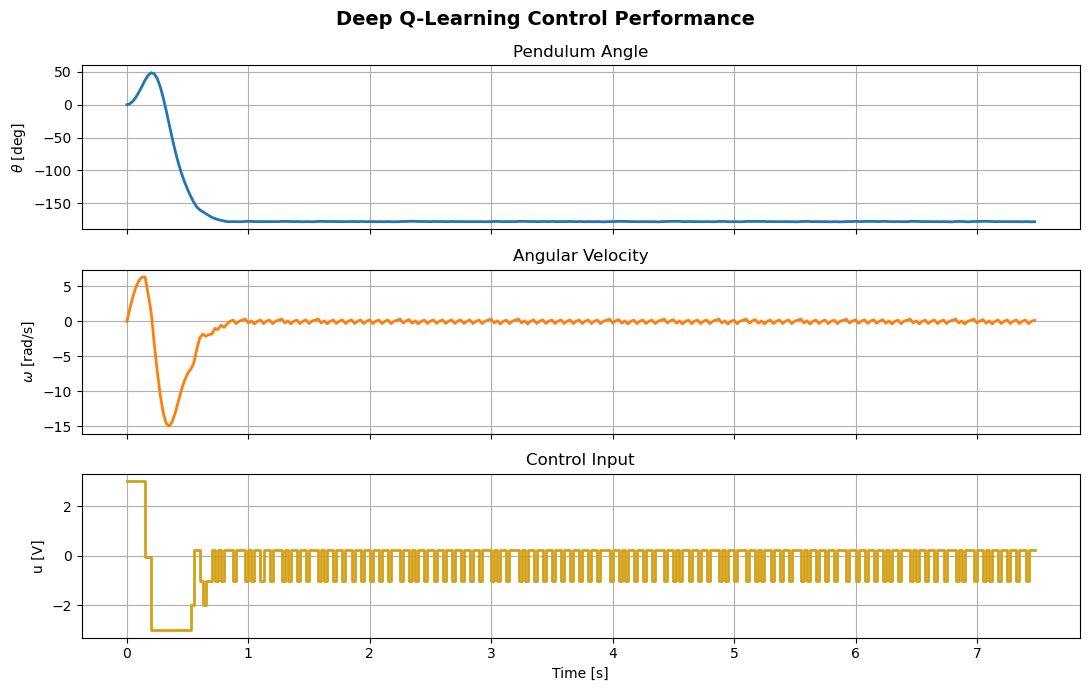

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Time axis
dt = 0.025
t = np.arange(len(theta_list)) * dt

fig, axs = plt.subplots(
    3, 1,
    figsize=(11, 7),
    sharex=True
)

fig.suptitle(
    'Deep Q-Learning Control Performance',
    fontsize=14,
    fontweight='bold'
)

# --------------------------------------------------
# Angle
# --------------------------------------------------

axs[0].plot(
    t,
    theta_list,
    color='#1f77b4',
    linewidth=2
)

axs[0].set_title('Pendulum Angle')
axs[0].set_ylabel(r'$\theta$ [deg]')
axs[0].grid(True)

# --------------------------------------------------
# Angular velocity
# --------------------------------------------------

axs[1].plot(
    t,
    omega_list,
    color='#ff7f0e',
    linewidth=2
)

axs[1].set_title('Angular Velocity')
axs[1].set_ylabel(r'$\omega$ [rad/s]')
axs[1].grid(True)

# --------------------------------------------------
# Control voltage
# --------------------------------------------------

axs[2].step(
    t,
    u_list,
    where='post',
    color='#d4a017',
    linewidth=2
)

axs[2].set_title('Control Input')
axs[2].set_ylabel('u [V]')
axs[2].set_xlabel('Time [s]')
axs[2].grid(True)

plt.tight_layout()
plt.savefig('DQL_simulation.png', dpi=300, bbox_inches='tight')
plt.show()